In [1]:
import pandas as pd
import csv
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import math
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker

### Definition of each interval (33,33 ms)

In [ ]:
STEP_TIME = 33.33

## Number of spikes metric (spikes per time interval)

In [ ]:
def has_any(values_set, candidates):
    return any(c in values_set for c in candidates)

def attack_label(df_stimulus):

    attacks = set(df_stimulus["attack"].dropna())
    init_vals = set(df_stimulus["init_attack"].dropna()) if "init_attack" in df_stimulus else set()
    inst_vals = set(df_stimulus["instant_attack"].dropna()) if "instant_attack" in df_stimulus else set()

    JAM_JAM = {"23064,23103", "9799,9837", "2999,3038"}
    JAM_SINGLE  = {23064, 9799, 2999}

    FLO_FLO = {"23081,23086", "9815,9821", "3016,3021"}
    FLO_SINGLE  = {23081, 9815, 3016}

    FLO_JAM = {23081, 9815, 3016}
    JAM_FLO = {23064, 9799, 2999}

    new_attack = None

    if "CONN_JAM" in attacks:
        if has_any(init_vals, JAM_JAM):
            new_attack = "JAM-JAM"
        elif has_any(init_vals, JAM_SINGLE):
            new_attack = "JAM"

    elif "CONN_FLO" in attacks:
        if has_any(inst_vals, FLO_FLO):
            new_attack = "FLO-FLO"
        elif has_any(inst_vals, FLO_SINGLE):
            new_attack = "FLO"

    elif "CONN_FLO_JAM" in attacks:
        if has_any(inst_vals, FLO_JAM):
            new_attack = "FLO-JAM"

    elif "CONN_JAM_FLO" in attacks:
        if has_any(init_vals, JAM_FLO):
            new_attack = "JAM-FLO"

    elif "Spontaneous" in attacks:
        new_attack = "Spontaneous"

    elif "noInput" in attacks:
        new_attack = "Blindness"

    if new_attack is not None:
        df_stimulus["attack"] = new_attack

In [ ]:
def number_spikes(df_stimulus):
    # This function first rounds the timestamp values in the given dataframe and divides them by 33.33 ms (the previously defined STEP_TIME). 
    # Based on the results, the function generates a new column called "position", which represents the time interval on the final plot.
    df_stimulus["timestamps"] = df_stimulus["timestamps"].round(1)
    df_stimulus['position'] = 0
    df_stimulus['position'] = df_stimulus['timestamps']/STEP_TIME
    df_stimulus['position'] = df_stimulus['position'].apply(lambda x: np.floor(x))
    df_stimulus['position'] = df_stimulus['position'].astype(int)

    # Secondly, the function creates another column that specifies which attack is being executed.
    attack_label(df_stimulus)

    # Finally, the function counts the number of neurons for each timestamp and position, and returns the resulting dataframe.
    df_stimulus = pd.DataFrame(df_stimulus.groupby(["attack","n_exec","timestamps","position"])["neuron_ids"].count())
    df_stimulus.reset_index(inplace=True)

    return df_stimulus

def compute_num_spikes(df_stimulus):
    # This function computes the number of spikes per position. 
    df_stimulus['n_spikes'] = df_stimulus['neuron_ids']
    df_stimulus['position'] += 1
    
    # Based on the count realised in the previous function, the function aggregates the data by attack, execution number, and position,
    # computing the total number of spikes for each position. 
    df_stimulus = pd.DataFrame(df_stimulus.groupby(["attack","n_exec","position"])["n_spikes"].sum())
    df_stimulus.reset_index(inplace=True)

    if (df_stimulus["attack"] == "Blindness").any():
        positions = list(df_stimulus[df_stimulus.attack == "Blindness"].position)
        ran = range(1,901)
        new_row=[]
        for i in ran:
            if not i in positions:
                new_row = pd.DataFrame({'attack': 'Blindness','n_exec': df_stimulus.loc[i, 'n_exec'],'position': [i],'n_spikes': 0})
                df_stimulus = pd.concat([df_stimulus,new_row],ignore_index=True)

    return df_stimulus

## Percentage of spike reduction per time interval, PSR(i)

In [4]:
from matplotlib.legend_handler import HandlerPatch
from matplotlib.patches import FancyArrowPatch
class HandlerArrow(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        center = height / 2
        p = FancyArrowPatch(
            (xdescent, center), (xdescent + width, center),
            arrowstyle="->", color=orig_handle.get_edgecolor(),
            lw=orig_handle.get_linewidth(), mutation_scale=fontsize
        )
        p.set_transform(trans)
        return [p]

In [ ]:
from matplotlib.patches import FancyArrowPatch

def percentage_reduction(df_stimulus_attck,df_stimulus_spon,df_stimulus_noLGN):
    # Firstly, this function denotes the range defined between the maximum spike number (spontaneous activity) 
    # and the minimum spike value blindness condition).
    df_range = pd.concat([df_stimulus_spon, df_stimulus_noLGN])
    ranges = df_range.groupby('position')['n_spikes'].agg(['min', 'max']).reset_index()
    
    # Secondly, it merges the number of spikes of the attack with the range to obtain the minimum and the maximum spikes for each position.
    df = df_stimulus_attck.merge(ranges, on='position', how='left')
    
    # Avoid division by zero
    df['range'] = df['max'] - df['min']
    
    df['reduction_%'] = np.where(
            # If any of the following values are invalid, there is insufficient data to calculate. 
            df['min'].isna() | df['max'].isna(),
            np.nan,
            # If not, the function verifies if the range is not 0. Then subtract the maximum by the number of spikes in the attack, and divide by the range. 
            # Lastly, multiply by 100 to obtain the percentage.
            np.where(
                df['range'] == 0,
                0.0, 
                (df['max'] - df['n_spikes']) / df['range'] * 100
            )
        )

    # Finally, the function returns the PSR for each time interval.
    df_resultado = df_stimulus_attck.copy()
    df_resultado['reduction_%'] = df['reduction_%']
    
    return df_resultado

### The following function plots the results of the analysis of a single attack with its sequential repetition and mixed-type:

In [ ]:
def plot_percentage_reduction_mixed(df_first, df_second, instant):
    
    plt.rcParams.update({'font.family': 'monospace'})
    sns.set(style="whitegrid",font_scale=2.5, rc={'figure.figsize':(40,20)})
    plt.rcParams['axes.edgecolor'] = "black" #set the value globally
    sns.set_palette("colorblind")

    label_size = 110
    ticks_size = 110
    legend_size = 110
    line_size = 60

    # Plot scale for the two grahps.
    # df_first represents the left plot from the figure, whereas df_second describes the right plot.
    fig, (ax1,ax2) = plt.subplots(1, 2, sharey=True, figsize=(120, 50), gridspec_kw={'width_ratios': [1, 1]})

    if instant == 693:
        sns.pointplot(x="position", y="deviation_%", hue = "attack",data= df_first[(df_first.position >= 691) & (df_first.position <= 711)],scale=8.2, ax=ax1)
        sns.pointplot(x="position", y="deviation_%", hue = "attack",data= df_second[(df_second.position >= 691) & (df_second.position <= 711)],scale=8.2, ax=ax2)

    elif instant == 295:
        sns.pointplot(x="position", y="deviation_%", hue = "attack",data= df_first[(df_first.position >= 293) & (df_first.position <= 313)],scale=8.2, ax=ax1)
        sns.pointplot(x="position", y="deviation_%", hue = "attack",data= df_second[(df_second.position >= 293) & (df_second.position <= 313)],scale=8.2, ax=ax2)

    elif instant == 91:
        sns.pointplot(x="position", y="deviation_%", hue = "attack",data= df_first[(df_first.position >= 89) & (df_first.position <= 109)],scale=8.2, ax=ax1)
        sns.pointplot(x="position", y="deviation_%", hue = "attack",data= df_second[(df_second.position >= 89) & (df_second.position <= 109)],scale=8.2, ax=ax2)
    
    for ax in (ax1, ax2):
        ymin, ymax = ax.get_ylim()
        ymin_extended = ymin - 0.1 * (ymax - ymin)  
        ymax_extended = ymax + 100 * (ymax - ymin)  

        for line in ax.lines:
            line.set_linewidth(23.0)

    # The function defines the arrow for each attack.
    # These arrows are the visual representation of Temporal attack propagation (TAP).
    arrow_b = FancyArrowPatch(
    (0, 0.5), (1, 0.5), 
    arrowstyle='->', color='#0072b2', lw=20,  mutation_scale=100
    )

    arrow_o = FancyArrowPatch(
    (0, 0.5), (1, 0.5), 
    arrowstyle='->', color='#E69F00', lw=20,  mutation_scale=100
    )

    arrow_z = FancyArrowPatch(
    (0, 0.5), (1, 0.5), 
    arrowstyle='->', color='#009e73', lw=20,  mutation_scale=100
    )
    # LEFT GRAPH OF THE FIGURE.
    # The next condition analyzes the single JAM with the consecutive repetition (JAM-JAM).
    if "JAM-JAM" in df_first["attack"].values:
        # The gray and the light blue shading represent the first and second JAM attacks.
        ax1.axvspan(2, 3, color="gray", alpha=0.2)
        ax1.axvspan(3.2, 4.2, color="#17becf", alpha=0.2)
        ax1.vlines([2, 3], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        ax1.vlines([3.2, 4.2], ymin=ymin_extended, ymax=ymax_extended, color="#096772", linewidth=2, zorder=1)

        # Then, it establishes the legend of the plot.
        handles1, labels1 = ax1.get_legend_handles_labels()
        leg_first= ax1.legend(handles=[*handles1, arrow_b, arrow_o], labels=[*labels1, 'JAM Propagation', 'JAM-JAM Propagation'], handler_map={FancyArrowPatch: HandlerArrow()},loc='best', fancybox=True, shadow=True, ncol=1, frameon='True',fontsize=legend_size)  
        leg_first.get_frame().set_edgecolor('black')
        # Representation of the attack propagation according to the attack interval.
        # The single JAM is illustrated with blue, while JAM-JAM is represented in orange.
        if instant == 693:
            ax1.annotate(
            '', xy=(7.1, -6.5), xytext=(2, -6.5),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100)
            )

            ax1.annotate(
            '', xy=(15.1, -9.5), xytext=(2, -9.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100)
            )
        elif instant == 295:
            ax1.annotate(
            '', xy=(11.1, -32.5), xytext=(2, -32.5),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100)
            )

            ax1.annotate(
            '', xy=(14.1, -35.5), xytext=(2, -35.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100)
            )
        elif instant == 91:
            ax1.annotate(
            '', xy=(12.1, -8.2), xytext=(2, -8.2),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100)
            )

            ax1.annotate(
            '', xy=(15.1, -11.2), xytext=(2, -11.2),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100)
            )
    # In this case, the JAM-FLO is analyze with single JAM and FLO.
    elif "JAM-FLO" in df_first["attack"].values:
        # The gray shows the first JAM and the light blue represents the second FLO.
        ax1.axvspan(2, 3, color="gray", alpha=0.2)
        ax1.axvspan(3.2, 3.5, color="#17becf", alpha=0.2)
        ax1.vlines([2, 3], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        ax1.vlines([3.2, 3.5], ymin=ymin_extended, ymax=ymax_extended, color="#096772", linewidth=2, zorder=1)

        # Then, it establishes the legend of the plot.
        handles1, labels1 = ax1.get_legend_handles_labels()
        leg_first= ax1.legend(handles=[*handles1, arrow_b, arrow_o, arrow_z], labels=[*labels1, 'JAM Propagation', 'FLO Propagation','JAM-FLO Propagation'], handler_map={FancyArrowPatch: HandlerArrow()},loc='best', fancybox=True, shadow=True, ncol=1, frameon='True',fontsize=legend_size)  
        leg_first.get_frame().set_edgecolor('black')

        # Representation of the attack propagation according to the attack interval.
        # The single JAM is illustrated with blue, the single FLO in orange and JAM-FLO in green.
        if instant == 693:
            ax1.annotate(
            '', xy=(7.1, -6.5), xytext=(2, -6.5),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100, zorder=3)
            )

            ax1.annotate(
            '', xy=(4.1, -9.5), xytext=(2, -9.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100, zorder=2)
            )

            ax1.annotate(
            '', xy=(11.1, -12.5), xytext=(2, -12.5),
            arrowprops=dict(arrowstyle='->', color='#009e73', lw=25, mutation_scale=100, zorder=1)
            )
        elif instant == 295:
            ax1.annotate(
            '', xy=(11.1, -20.5), xytext=(2, -20.5),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100)
            )

            ax1.annotate(
            '', xy=(6.1, -23.5), xytext=(2, -23.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100)
            )

            ax1.annotate(
            '', xy=(20.5, -26.5), xytext=(2, -26.5),
            arrowprops=dict(arrowstyle='->', color='#009e73', lw=25, mutation_scale=100, zorder=1)
            )
        elif instant == 91:
            ax1.annotate(
            '', xy=(12.1, -6.5), xytext=(2, -6.5),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100)
            )

            ax1.annotate(
            '', xy=(5.1, -9.5), xytext=(2, -9.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100, zorder=2)
            )

            ax1.annotate(
            '', xy=(15.1, -12.5), xytext=(2, -12.5),
            arrowprops=dict(arrowstyle='->', color='#009e73', lw=25, mutation_scale=100)
            )
    # RIGHT GRAPH OF THE FIGURE.
    # Analysis of the single FLO with its sequential repetition (FLO-FLO).
    if "FLO-FLO" in df_second["attack"].values:
        # The gray and the light blue shading represent the first and second FLO attack.
        ax2.axvspan(2.1, 2.4, color="gray", alpha=0.2)
        ax2.axvspan(2.6, 2.9, color="#17becf", alpha=0.2)
        ax2.vlines([2.1, 2.4], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        ax2.vlines([2.6, 2.9], ymin=ymin_extended, ymax=ymax_extended, color="#096772", linewidth=2, zorder=1)

        # Creation of the legend within the plot.
        handles2, labels2 = ax2.get_legend_handles_labels()
        leg_second= ax2.legend(handles=[*handles2, arrow_b, arrow_o], labels=[*labels2, 'FLO Propagation', 'FLO-FLO Propagation'], handler_map={FancyArrowPatch: HandlerArrow()},loc='best', fancybox=True, shadow=True, ncol=1, frameon='True',fontsize=legend_size)  
        leg_second.get_frame().set_edgecolor('black')

        # Representation of the attack propagation according to the attack interval.
        # The single FLO is illustrated with blue, while FLO-FLO is represented in orange.
        if instant == 693:
            ax2.annotate(
            '', xy=(4.1, -6.5), xytext=(2, -6.5),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100)
            )

            ax2.annotate(
            '', xy=(5.1, -9.5), xytext=(2, -9.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100)
            )
        elif instant == 295:
            ax2.annotate(
            '', xy=(6.1, -32.5), xytext=(2, -32.5),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100)
            )

            ax2.annotate(
            '', xy=(6.1, -35.5), xytext=(2, -35.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100)
            )
        elif instant == 91:
            ax2.annotate(
            '', xy=(5.1, -8.2), xytext=(2, -8.2),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100)
            )

            ax2.annotate(
            '', xy=(8.1, -11.2), xytext=(2, -11.2),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100)
            )
    # Evaluation of mixed-type attack (FLO-JAM) with single JAM and FLO.
    elif "FLO-JAM" in df_second["attack"].values:
        # The gray shows the first FLO, and the light blue represents the second JAM.
        ax2.axvspan(2.1, 2.4, color="gray", alpha=0.2)
        ax2.axvspan(2.8, 3.8, color="#17becf", alpha=0.2)
        ax2.vlines([2.1, 2.4], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        ax2.vlines([2.8, 3.8], ymin=ymin_extended, ymax=ymax_extended, color="#096772", linewidth=2, zorder=1)

        # Creation of the legend within the plot.
        handles2, labels2 = ax2.get_legend_handles_labels()
        leg_second= ax2.legend(handles=[*handles2, arrow_b, arrow_o, arrow_z], labels=[*labels2,'JAM Propagation', 'FLO Propagation', 'FLO-JAM Propagation'], handler_map={FancyArrowPatch: HandlerArrow()},loc='best', fancybox=True, shadow=True, ncol=1, frameon='True',fontsize=legend_size)  
        leg_second.get_frame().set_edgecolor('black')

        # Representation of the attack propagation according to the attack interval.
        # The single JAM is shown in blue, the single FLO in orange, and FLO-JAM in green.
        if instant == 693:
            ax2.annotate(
            '', xy=(7.1, -6.5), xytext=(2, -6.5),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100)
            )
            ax2.annotate(
            '', xy=(4.1, -9.5), xytext=(2, -9.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100)
            )

            ax2.annotate(
            '', xy=(11.1, -12.5), xytext=(2, -12.5),
            arrowprops=dict(arrowstyle='->', color='#009e73', lw=25, mutation_scale=100)
            )
        elif instant == 295:
            ax2.annotate(
            '', xy=(11.1, -20.5), xytext=(2, -20.5),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100)
            )
            ax2.annotate(
            '', xy=(6.1, -23.5), xytext=(2, -23.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100)
            )

            ax2.annotate(
            '', xy=(19.1, -26.5), xytext=(2, -26.5),
            arrowprops=dict(arrowstyle='->', color='#009e73', lw=25, mutation_scale=100)
            )
        elif instant == 91:
            ax2.annotate(
            '', xy=(12.1, -6.5), xytext=(2, -6.5),
            arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100)
            )
            ax2.annotate(
            '', xy=(5.1, -9.5), xytext=(2, -9.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100)
            )

            ax2.annotate(
            '', xy=(14.1, -12.5), xytext=(2, -12.5),
            arrowprops=dict(arrowstyle='->', color='#009e73', lw=25, mutation_scale=100)
            )

    # Set of configurations for the final plot.
    for ax in (ax1, ax2):
        ax.tick_params(labelsize=ticks_size)

        # ax.set_ylim(-40, 80) # ylim for 295 interval in consecutive attack analysis
        # ax.set_ylim(-30, 80) # ylim for 295 interval in mixed-type attack analysis
        ax.set_ylim(-15, 80)
        ax.set_xlim(-0.5, 20.5)
        ax.yaxis.set_major_locator(MultipleLocator(10))

        ax.set_xlabel('') 
        ax.set_ylabel('') 

        for label in ax.get_xticklabels():
            label.set_rotation(70)
        for label in ax.get_yticklabels():
            label.set_rotation(50)
        ax.xaxis.grid(True)
        
        ax.set_xlabel("Time interval", fontsize=label_size, fontweight="bold")

    ax1.set_ylabel("Percentage of spike reduction", fontsize=label_size, fontweight="bold")

    plt.tight_layout()
    plt.savefig("./Figure6c.pdf",bbox_inches='tight')

The next function plots the results of the different multiple attacks:

In [ ]:
def plot_percentage_reduction_comb(df_comb, instant):
    
    plt.rcParams.update({'font.family': 'monospace'})
    sns.set(style="whitegrid",font_scale=2.5, rc={'figure.figsize':(40,20)})
    plt.rcParams['axes.edgecolor'] = "black" #set the value globally
    sns.set_palette("colorblind")

    label_size = 110
    ticks_size = 110
    legend_size = 110
    line_size = 60

    # Plot scale.
    fig, ax = plt.subplots(figsize=(80,60))
    
    if instant == 693:
        sns.pointplot(x="position", y="deviation_%", hue = "attack",data= df_comb[(df_comb.position >= 691) & (df_comb.position <= 711)],scale=8.2, ax=ax)
    elif instant == 295:
        sns.pointplot(x="position", y="deviation_%", hue = "attack", data= df_comb[(df_comb.position >= 293) & (df_comb.position <= 313)],scale=8.2, ax=ax)
    elif instant == 91:
        sns.pointplot(x="position", y="deviation_%", hue = "attack",data= df_comb[(df_comb.position >= 89) & (df_comb.position <= 109)],scale=8.2, ax=ax)
        
    for line in ax.lines:
        line.set_linewidth(23.0)

    # The function defines the arrow for each attack.
    arrow_b = FancyArrowPatch(
    (0, 0.5), (1, 0.5), 
    arrowstyle='->', color='#0072b2', lw=20,  mutation_scale=100
    )

    arrow_o = FancyArrowPatch(
    (0, 0.5), (1, 0.5), 
    arrowstyle='->', color='#E69F00', lw=20,  mutation_scale=100
    )

    arrow_z = FancyArrowPatch(
    (0, 0.5), (1, 0.5), 
    arrowstyle='->', color='#009e73', lw=20,  mutation_scale=100
    )

    arrow_y = FancyArrowPatch(
    (0, 0.5), (1, 0.5), 
    arrowstyle='->', color='#D55E00', lw=20,  mutation_scale=100
    )
    
    # Creation of the legend within the plot.
    handles1, labels1 = ax.get_legend_handles_labels()
    leg_first= ax.legend(handles=[*handles1, arrow_b, arrow_o, arrow_z,arrow_y], labels=[*labels1, 'JAM-JAM Propagation','FLO-FLO Propagation', 'JAM-FLO Propagation','FLO-JAM Propagation'], handler_map={FancyArrowPatch: HandlerArrow()},loc='best', fancybox=True, shadow=True, ncol=1, frameon='True',fontsize=legend_size)  
    leg_first.get_frame().set_edgecolor('black')

    # Representation of the attack propagation according to the attack interval.
    # According to the attack, it is represented as follows:
    # JAM-JAM -> BLUE, FLO-FLO -> ORANGE, JAM-FLO -> GREEN, FLO-JAM -> RED
    if instant == 693:
        ax.annotate(
        '', xy=(15.1, -6.5), xytext=(2, -6.5),
        arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100, zorder=3)
        )

        ax.annotate(
            '', xy=(5.1, -9.5), xytext=(2, -9.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100, zorder=3)
            )
   
        ax.annotate(
        '', xy=(11.1, -12.5), xytext=(2, -12.5),
        arrowprops=dict(arrowstyle='->', color='#009e73', lw=25, mutation_scale=100, zorder=2)
        )

        ax.annotate(
        '', xy=(11.1, -15.5), xytext=(2, -15.5),
        arrowprops=dict(arrowstyle='->', color='#D55E00', lw=25, mutation_scale=100, zorder=1)
        )
    elif instant == 295:
        ax.annotate(
        '', xy=(14.1, -32.5), xytext=(2, -32.5),
        arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100, zorder=3)
        )
  
        ax.annotate(
            '', xy=(6.1, -35.5), xytext=(2, -35.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100, zorder=3)
            )
 
        ax.annotate(
        '', xy=(20.5, -38.5), xytext=(2, -38.5),
        arrowprops=dict(arrowstyle='->', color='#009e73', lw=25, mutation_scale=100, zorder=2)
        )

        ax.annotate(
        '', xy=(19.1, -41.5), xytext=(2, -41.5),
        arrowprops=dict(arrowstyle='->', color='#D55E00', lw=25, mutation_scale=100, zorder=1)
        )
    elif instant == 91:
        ax.annotate(
        '', xy=(15.1, -8.5), xytext=(2, -8.5),
        arrowprops=dict(arrowstyle='->', color='#0072b2', lw=25, mutation_scale=100, zorder=3)
        )
 
        ax.annotate(
            '', xy=(8.1, -11.5), xytext=(2, -11.5),
            arrowprops=dict(arrowstyle='->', color='#E69F00', lw=25, mutation_scale=100, zorder=3)
            )
 
        ax.annotate(
        '', xy=(15.1, -14.5), xytext=(2, -14.5),
        arrowprops=dict(arrowstyle='->', color='#009e73', lw=25, mutation_scale=100, zorder=2)
        )
   
        ax.annotate(
        '', xy=(14.1, -17.5), xytext=(2, -17.5),
        arrowprops=dict(arrowstyle='->', color='#D55E00', lw=25, mutation_scale=100, zorder=1)
        )
 
    # Set of configurations for the final plot.
    # ax.set_ylim(-45, 80) # ylim for 295 interval 
    ax.set_ylim(-20, 80)
    ax.set_xlim(-0.5, 20.5)
    ax.yaxis.set_major_locator(MultipleLocator(10))

    ax.set_xlabel('')  
    ax.set_ylabel('') 
    ax.tick_params(labelsize=ticks_size)

    for label in ax.get_xticklabels():
        label.set_rotation(70)
    for label in ax.get_yticklabels():
        label.set_rotation(50)
    ax.xaxis.grid(True)
    
    ax.set_xlabel("Time interval", fontsize=label_size, fontweight="bold")
    ax.set_ylabel("Percentage of spike reduction", fontsize=label_size, fontweight="bold")
  
    plt.tight_layout()
    plt.savefig("./Figure7c.pdf",bbox_inches='tight')


## Use cases of PSR:

### Single attacks vs sequential repetition/mixed-type attacks

In [ ]:
df_noLGN = pd.read_csv("./output_noLGN_movieone/spikes_0.csv", delimiter=";")
df_spontaneous = pd.read_csv("./spontaneous_30s_movie_one/spikes_0.csv", delimiter=";")

df_JAM = pd.read_csv("./output_JAM_VisL4_e_2999-3033ms_alln_movieone/spikes_0.csv", delimiter=";")
df_FLO = pd.read_csv("./output_FLO_VisL4_i_3016ms_alln_movieone/spikes_0.csv", delimiter=";")

df_JAMFLO = pd.read_csv("./output_JAM_FLO_VisL4_ei_2999-3033ms_3038ms_alln_movieone/spikes_0.csv", delimiter=";")
df_FLOJAM = pd.read_csv("./output_FLO_JAM_VisL4_ie_3016ms_3021-3055ms_alln_movieone/spikes_0.csv", delimiter=";")


In [ ]:
df_noLGN_spikes = number_spikes(df_noLGN)
df_spontaneous_spikes = number_spikes(df_spontaneous)

df_JAM_spikes = number_spikes(df_JAM)
df_FLO_spikes = number_spikes(df_FLO)

df_JAMFLO_spikes = number_spikes(df_JAMFLO)
df_FLOJAM_spikes = number_spikes(df_FLOJAM)

In [ ]:
df_noLGN_numspikes = compute_num_spikes(df_noLGN_spikes)
df_spontaneous_numspikes = compute_num_spikes(df_spontaneous_spikes)

df_JAM_numspikes = compute_num_spikes(df_JAM_spikes)
df_FLO_numspikes = compute_num_spikes(df_FLO_spikes)

df_JAMFLO_numspikes = compute_num_spikes(df_JAMFLO_spikes)
df_FLOJAM_numspikes = compute_num_spikes(df_FLOJAM_spikes)

In [ ]:
reduction_JAM = percentage_reduction(df_JAM_numspikes,df_spontaneous_numspikes,df_noLGN_numspikes)
reduction_FLO = percentage_reduction(df_FLO_numspikes,df_spontaneous_numspikes,df_noLGN_numspikes)

reduction_JAMFLO = percentage_reduction(df_JAMFLO_numspikes,df_spontaneous_numspikes,df_noLGN_numspikes)
reduction_FLOJAM = percentage_reduction(df_FLOJAM_numspikes,df_spontaneous_numspikes,df_noLGN_numspikes)

first_plt = pd.concat([reduction_JAM, reduction_FLO, reduction_JAMFLO], ignore_index=True)
second_plt = pd.concat([reduction_JAM, reduction_FLO, reduction_FLOJAM], ignore_index=True)

In [ ]:
plot_percentage_reduction_mixed(first_plt, second_plt, 91)

/tmp/ipykernel_6438/733195764.py:26: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(x="position", y="deviation_%", hue = "attack",data= df_first[(df_first.position >= 89) & (df_first.position <= 109)],scale=8.2, ax=ax1)
/tmp/ipykernel_6438/733195764.py:28: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(x="position", y="deviation_%", hue = "attack",data= df_second[(df_second.position >= 89) & (df_second.position <= 109)],scale=8.2, ax=ax2)


### Different multiple attacks

In [ ]:
df_noLGN = pd.read_csv("./output_noLGN_movieone/spikes_0.csv", delimiter=";")
df_spontaneous = pd.read_csv("./spontaneous_30s_movie_one/spikes_0.csv", delimiter=";")

df_JAMJAM = pd.read_csv("./output_JAM_JAM_VisL4_e_2999-3033ms_3038-3071ms_alln_movieone/spikes_0.csv", delimiter=";")
df_FLOFLO = pd.read_csv("./output_FLO_FLO_VisL4_i_3016_3021ms_alln_movieone/spikes_0.csv", delimiter=";")

df_JAMFLO = pd.read_csv("./output_JAM_FLO_VisL4_ei_2999-3033ms_3038ms_alln_movieone/spikes_0.csv", delimiter=";")
df_FLOJAM = pd.read_csv("./output_FLO_JAM_VisL4_ie_3016ms_3021-3055ms_alln_movieone/spikes_0.csv", delimiter=";")

In [ ]:
df_noLGN_spikes = number_spikes(df_noLGN)
df_spontaneous_spikes = number_spikes(df_spontaneous)

df_JAMJAM_spikes = number_spikes(df_JAMJAM)
df_FLOFLO_spikes = number_spikes(df_FLOFLO)

df_JAMFLO_spikes = number_spikes(df_JAMFLO)
df_FLOJAM_spikes = number_spikes(df_FLOJAM)

In [ ]:
df_noLGN_numspikes = compute_num_spikes(df_noLGN_spikes)
df_spontaneous_numspikes = compute_num_spikes(df_spontaneous_spikes)

df_JAMJAM_numspikes = compute_num_spikes(df_JAMJAM_spikes)
df_FLOFLO_numspikes = compute_num_spikes(df_FLOFLO_spikes)

df_JAMFLO_numspikes = compute_num_spikes(df_JAMFLO_spikes)
df_FLOJAM_numspikes = compute_num_spikes(df_FLOJAM_spikes)

In [ ]:
reduction_JAMJAM = percentage_reduction(df_JAMJAM_numspikes,df_spontaneous_numspikes,df_noLGN_numspikes)
reduction_FLOFLO = percentage_reduction(df_FLOFLO_numspikes,df_spontaneous_numspikes,df_noLGN_numspikes)
reduction_JAMFLO = percentage_reduction(df_JAMFLO_numspikes,df_spontaneous_numspikes,df_noLGN_numspikes)
reduction_FLOJAM = percentage_reduction(df_FLOJAM_numspikes,df_spontaneous_numspikes,df_noLGN_numspikes)

reduction_comb = pd.concat([reduction_JAMJAM,reduction_FLOFLO,reduction_JAMFLO,reduction_FLOJAM], ignore_index=True)

/tmp/ipykernel_4423/2207365086.py:22: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(x="position", y="deviation_%", hue = "attack",data= df_comb[(df_comb.position >= 89) & (df_comb.position <= 109)],scale=8.2, ax=ax)


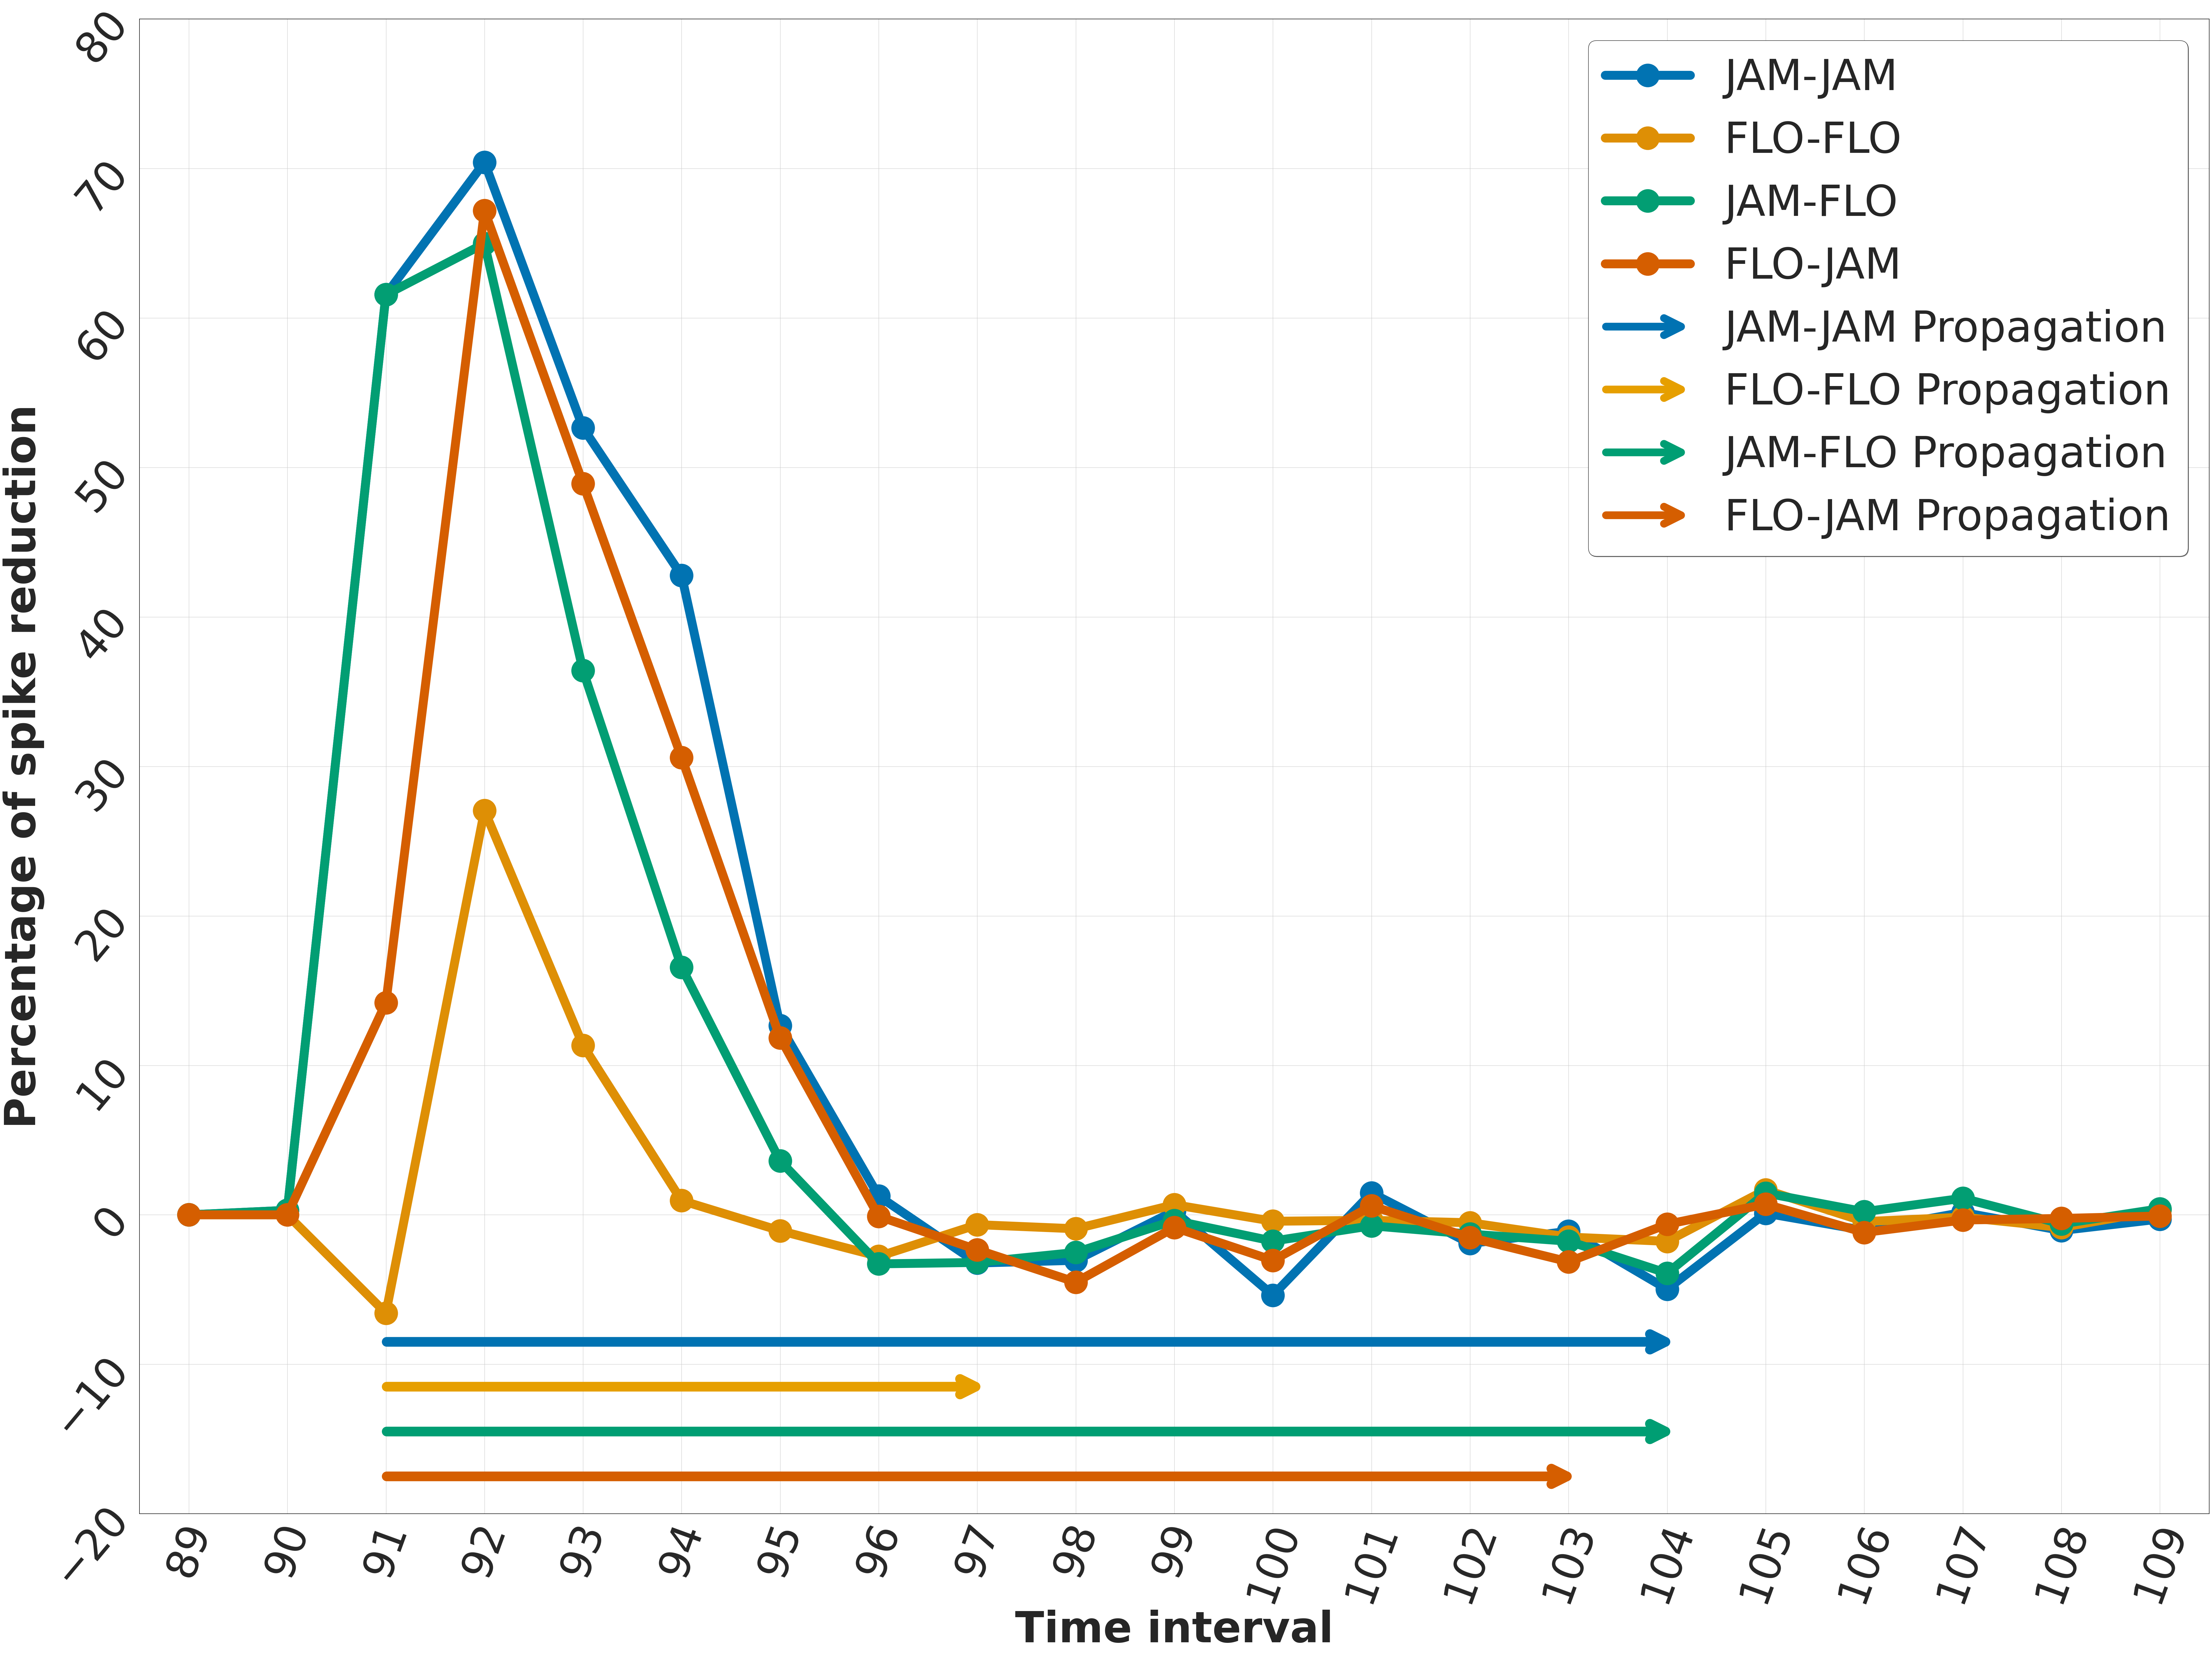

In [ ]:
plot_percentage_reduction_comb(reduction_comb, 91)

## Temporal attack propagation (TAP)

In [ ]:
def attack_propagation(df_stimulus_attck,df_stimulus_spon):
    # This function calculates the absolute difference between the number of spikes of spontaneous and the attack.
    # Besides, it calculates the threshold defined as 3% of the spike count of sponateous.
    difference = (df_stimulus_spon['n_spikes'] - df_stimulus_attck['n_spikes']).abs()
    threshold = df_stimulus_spon['n_spikes'] * 0.03

    # Creates a temporary dataframe.
    temp_df = df_stimulus_spon.copy()
    temp_df['difference'] = difference

    # Filters differences that exceed the threshold.
    temp_df = temp_df[difference >= threshold]

    # Then, it groups and counts by position.
    conteo = temp_df.groupby('position').size().reset_index(name='significant_difference_count')

    return conteo

def attack_propagation_total(df_stimulus_attck,df_stimulus_spon):
    difference = (df_stimulus_spon['n_spikes'] - df_stimulus_attck['n_spikes']).abs()
    threshold = df_stimulus_spon['n_spikes'] * 0.03
    total = (difference > threshold).sum()

    return total

## Use case of TAP:

In [ ]:
df_attck = pd.read_csv("./output_JAM_JAM_VisL4_e_2999-3033ms_3038-3071ms_alln_movieone/spikes_0.csv", delimiter=";")
df_spontaneous = pd.read_csv("./spontaneous_30s_movie_one/spikes_0.csv", delimiter=";")

df_attck_spikes = number_spikes(df_attck)
df_spontaneous_spikes = number_spikes(df_spontaneous)

df_attck_numspikes = compute_num_spikes(df_attck_spikes)
df_spontaneous_numspikes = compute_num_spikes(df_spontaneous_spikes)

In [ ]:
Tap = attack_propagation(df_attck_numspikes,df_spontaneous_numspikes)
Tap

,position,conteo_diferencia_significativa
0,91,1
1,92,1
2,93,1
3,94,1
4,96,1
5,97,1


In [ ]:
Tap_total = attack_propagation_total(df_attck_numspikes,df_spontaneous_numspikes)
Tap_total

,position,conteo_diferencia_significativa
0,693,1
1,694,1
2,695,1
3,696,1
4,697,1
5,729,1
